# Feature Hierarchy Explorer: a hands-on review

This notebook is a human-oriented tour of the explorer in `bea-tools`. It uses a small synthetic clinical-style table so every count can be checked by eye. Nothing here assumes real patient data.

The explorer deliberately separates four questions:

1. **Independent levels (S1):** What values occur in each column?
2. **Nested census (S2):** Which observed paths occur in an ordered hierarchy?
3. **Grain evidence (S3):** Do supplied keys determine other columns in these observed rows?
4. **Pairs and absence:** How do dimensions map to one another, and which domain cells were not observed?

> Important: unobserved does not mean impossible, and an exact functional dependency in a sample is evidence—not proof of real-world semantics.

This tour also demonstrates **static SVG, interactive HTML, filtered presentation
data, and selected-pair joint counts**. The graphical examples sit beside their
analytical sections. Section 10 is an editable playground for trying your own
keys, display mode, limits, and section selection.

Run all cells from top to bottom first. From the repository root, a notebook
server with the required display tools can be started with:

```bash
uv run --group dev --with jupyterlab jupyter lab examples/feature-hierarchy-explorer.ipynb
```

Use a Python kernel that imports this checkout (the setup cell prints its path).
SVGs need no plotting extra or Graphviz. Interactive previews use isolated frames;
if your viewer suppresses them, trust this locally generated notebook or open the
standalone HTML files written to the printed output directory. Saved SVG outputs
remain readable without executing JavaScript. The output directory is newly
created for each run and does not modify the repository.


## 1. Setup and a reviewable dataset

The table includes repeated exams, two sites, two modalities, left/right sides, a missing finding, and one deliberate conflict for `(exam_id, side) = (E001, L)`.

In [1]:
import json
from html import escape
from pathlib import Path
from tempfile import mkdtemp

from IPython.display import HTML, SVG, display

import pandas as pd

import bea_tools
from bea_tools import (
    KeySpec,
    census,
    explore,
    grain,
    infer_schema,
    levels,
    joint_counts,
    render_svg,
    render_html,
    visualization_data,
    render_plaintext,
)

pd.set_option("display.max_columns", None)
print("bea_tools imported from:", bea_tools.__file__)
OUTPUT_DIR = Path(mkdtemp(prefix="bea-explorer-notebook-"))
print("Graphical exports:", OUTPUT_DIR)


def preview_html(document, filename, height=640):
    """Save the public renderer's output and isolate each preview's controls."""
    destination = OUTPUT_DIR / filename
    destination.write_text(document, encoding="utf-8")
    display(HTML(
        f'<iframe title="{escape(filename, quote=True)}" '
        f'srcdoc="{escape(document, quote=True)}" sandbox="allow-scripts" '
        f'style="width:100%;height:{height}px;border:1px solid #cbd5df;border-radius:8px">'
        '</iframe>'
    ))
    print("Standalone HTML (open this file if the preview is blocked):", destination)


df = pd.DataFrame(
    {
        "exam_id": ["E001", "E001", "E001", "E002", "E002", "E002", "E003", "E003", "E004", "E004"],
        "site": ["North", "North", "North", "North", "North", "North", "South", "South", "South", "South"],
        "modality": ["MRI", "MRI", "MRI", "CT", "CT", "CT", "MRI", "MRI", "CT", "CT"],
        "side": ["L", "L", "R", "L", "L", "R", "L", "R", "L", "R"],
        "finding": ["clear", "scar", "clear", "clear", "clear", "scar", "nodule", "nodule", "clear", None],
        "severity": [0, 1, 0, 0, 0, 1, 2, 2, 0, pd.NA],
    }
)

df

bea_tools imported from: /Users/beatrice/AgentFiles/projects/bea-tools/bea_tools/__init__.py
Graphical exports: /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j


,exam_id,site,modality,side,finding,severity
0,E001,North,MRI,L,clear,0
1,E001,North,MRI,L,scar,1
2,E001,North,MRI,R,clear,0
3,E002,North,CT,L,clear,0
4,E002,North,CT,L,clear,0
5,E002,North,CT,R,scar,1
6,E003,South,MRI,L,nodule,2
7,E003,South,MRI,R,nodule,2
8,E004,South,CT,L,clear,0
9,E004,South,CT,R,NaN,<NA>


Before using the combined explorer, we will call each analytical surface independently. This is useful when you only need one answer and want the smallest result.

## 2. S1: independent level counts

`levels()` counts every feature on its own population. A top-N limit for one feature never filters rows for another feature. Missing values count as a typed level unless `dropna=True`.

In [2]:
independent = levels(
    df,
    features=["site", "modality", "side", "finding"],
    top_n=3,
)
print(render_plaintext(independent, width=88, max_lines=40))

bea-tools feature explorer v0.3
Levels (computed)
  site: 2/2 levels; 10/10 evaluated rows reported
    'North': 6 rows
    'South': 4 rows
  modality: 2/2 levels; 10/10 evaluated rows reported
    'CT': 5 rows
    'MRI': 5 rows
  side: 2/2 levels; 10/10 evaluated rows reported
    'L': 6 rows
    'R': 4 rows
  finding: 3/4 levels; 9/10 evaluated rows reported
    'clear': 5 rows
    'nodule': 2 rows
    'scar': 2 rows
    ... 1 level / 1 row not reported


In [3]:
# Population accounting is explicit for each feature.
pd.DataFrame(
    {
        "feature": [entry["column"]["value"] for entry in independent["per_feature"]],
        "levels_total": [entry["levels_total"] for entry in independent["per_feature"]],
        "levels_reported": [entry["levels_reported"] for entry in independent["per_feature"]],
        "reported_rows": [entry["reported_rows"] for entry in independent["per_feature"]],
        "unreported_rows": [entry["unreported_rows"] for entry in independent["per_feature"]],
    }
)

,feature,levels_total,levels_reported,reported_rows,unreported_rows
0,site,2,2,10,0
1,modality,2,2,10,0
2,side,2,2,10,0
3,finding,4,3,9,1


**Review checkpoint:** `finding` has four typed levels: `clear`, `scar`, `nodule`, and missing. Because `top_n=3`, one level is omitted from display, but the omitted row mass remains explicit.

### Graphical levels: frequencies and topology

Full bars use each feature's evaluated population and keep omitted mass explicit.
Topology shows typed labels in canonical order, without frequency bars or counts.
Try changing `top_n` in the earlier cell and rerunning both figures.

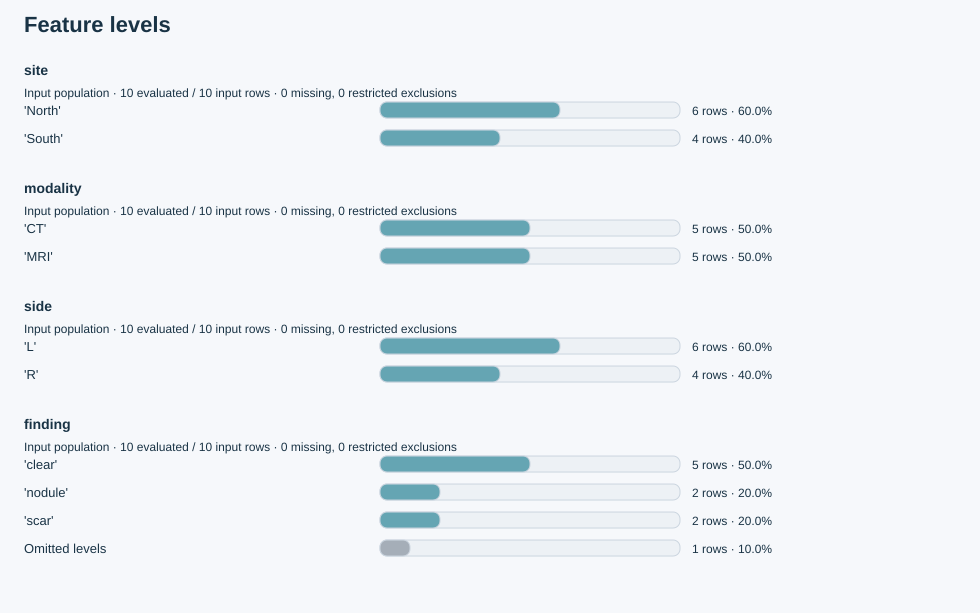

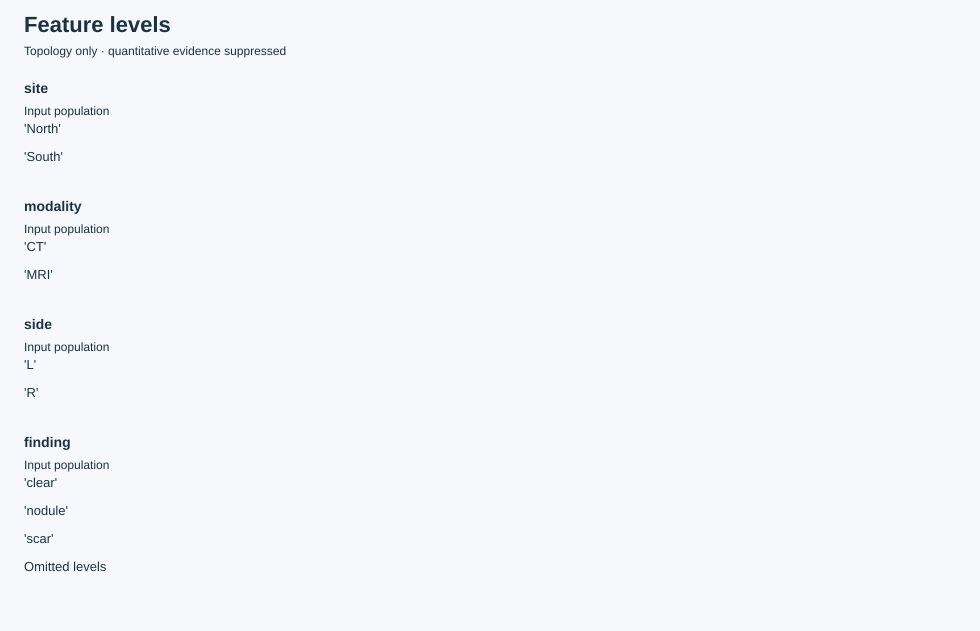

In [4]:
for detail in ("full", "topology"):
    display(HTML(f"<h4>Levels · {detail}</h4>"))
    display(SVG(render_svg(independent, detail=detail)))

## 3. S2: a bounded nested census

`census()` treats dimension order as meaningful. Here we ask for observed `site → modality → side → finding` prefixes. The default `top_n_mode="post"` preserves population counts while collapsing omitted branches. The plaintext view prints each parent with its descendants before moving to the next sibling, and names the dimension on every node. Root totals and omitted row counts remain visible even in totals-only requests.

In [5]:
nested = census(
    df,
    dimensions=["site", "modality", "side", "finding"],
    top_n=2,
    top_n_per_parent=True,
    max_nodes=40,
)
print(render_plaintext(nested, width=88, max_lines=60))

bea-tools feature explorer v0.3
Census (computed)
  rows: 10 evaluated / 10 input; excluded: 0 missing, 0 restricted
  path: site > modality > side > finding
  total: 10 rows
  site='North': 6 rows
    modality='CT': 3 rows
      side='L': 2 rows
        finding='clear': 2 rows
      side='R': 1 row
        finding='scar': 1 row
    modality='MRI': 3 rows
      side='L': 2 rows
        finding='clear': 1 row
        finding='scar': 1 row
      side='R': 1 row
        finding='clear': 1 row
  site='South': 4 rows
    modality='CT': 2 rows
      side='L': 1 row
        finding='clear': 1 row
      side='R': 1 row
        finding=<NA>: 1 row
    modality='MRI': 2 rows
      side='L': 1 row
        finding='nodule': 1 row
      side='R': 1 row
        finding='nodule': 1 row


In [6]:
# Every expanded parent conserves row mass.
nodes = {node["node_id"]: node for node in nested["tree"]["nodes"]}
nodes["root"] = nested["tree"]["root"]
checks = []
for parent in nodes.values():
    if parent["expansion_state"] != "expanded":
        continue
    child_total = sum(
        node["count"] for node in nodes.values() if node.get("parent_id") == parent["node_id"]
    )
    checks.append(
        {
            "parent": parent["node_id"],
            "parent_count": parent["count"],
            "emitted_children": child_total,
            "omitted_child_rows": parent["omitted_child_rows"],
            "conserved": parent["count"] == child_total + parent["omitted_child_rows"],
        }
    )
pd.DataFrame(checks)

,parent,parent_count,emitted_children,omitted_child_rows,conserved
0,n0,6,6,0,True
1,n1,4,4,0,True
2,n2,3,3,0,True
3,n3,3,3,0,True
4,n4,2,2,0,True
5,n5,2,2,0,True
6,n6,2,2,0,True
7,n7,1,1,0,True
8,n8,2,2,0,True
9,n9,1,1,0,True


### Conditional pre-selection

Pre mode is intentionally different: it selects retained levels first, intersects them into one common cohort, and recomputes every reported prefix on that cohort. The result is marked conditional.

In [7]:
conditional = census(
    df,
    dimensions=["site", "modality", "side"],
    top_n=1,
    top_n_mode="pre",
)
print(render_plaintext(conditional, width=88, max_lines=30))
pd.DataFrame(conditional["scopes"])

bea-tools feature explorer v0.3
Census (computed, conditional)
  rows: 2 evaluated / 10 input; excluded: 0 missing, 8 restricted
  path: site > modality > side
  total: 2 rows
  site='North': 2 rows
    modality='CT': 2 rows
      side='L': 2 rows


,scope_id,input_rows,missing_excluded_rows,restriction_excluded_rows,evaluated_rows,retained_rows,conditional,lineage
0,s2,10,0,8,2,2,True,"[input, include_missing, pre]"


**Review checkpoint:** compare `input_rows`, `restriction_excluded_rows`, and `evaluated_rows`. Output limits do not silently change these population definitions.

### Graphical census: a distribution tree

The static tree aligns bars to the total evaluated population. Its omission rows
retain their own mass. In the HTML preview, use the **↕ buttons** to collapse and
expand branches; the table also reports shares of each parent. The same API can
render `conditional` to inspect the effect of pre-selection.

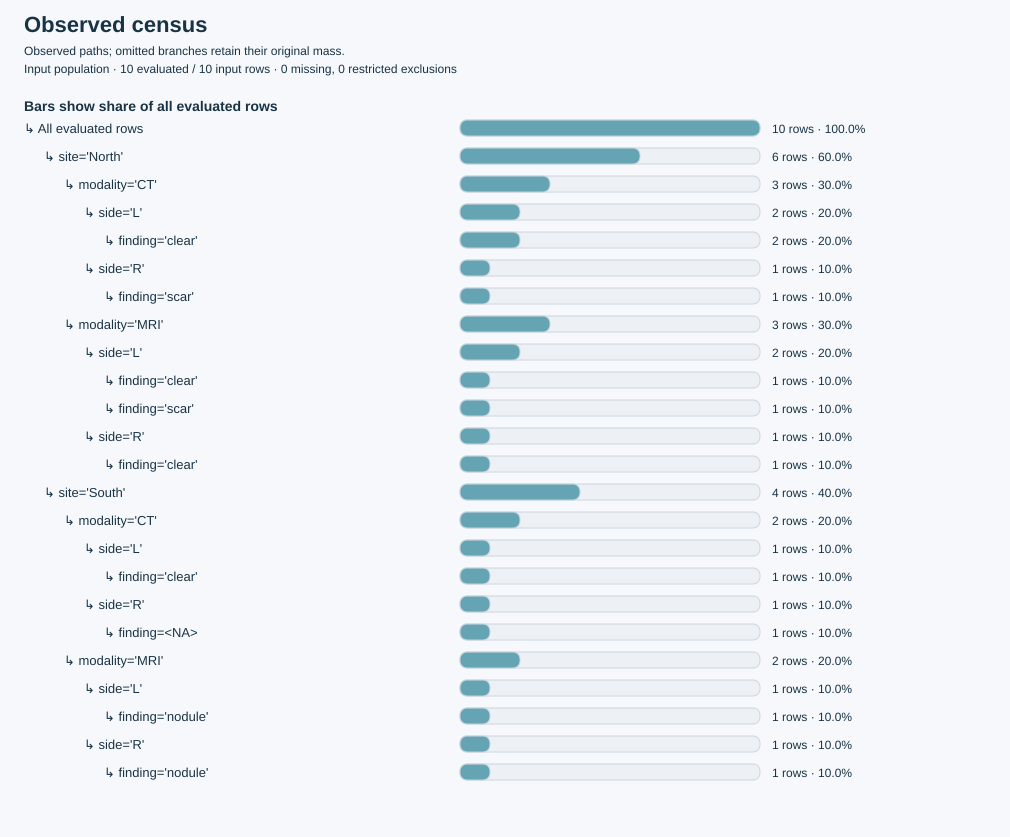

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/census-full.html


In [8]:
display(SVG(render_svg(nested)))
preview_html(render_html(nested), "census-full.html")

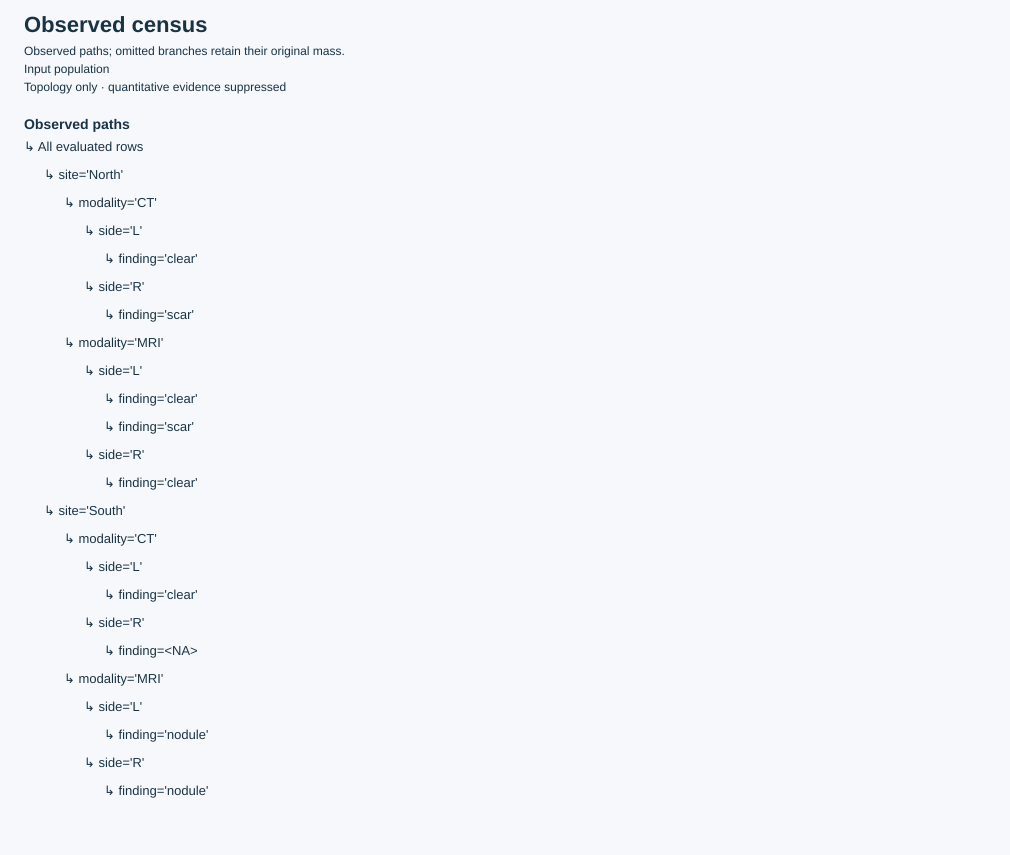

Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/census-topology.html


In [9]:
display(SVG(render_svg(nested, detail="topology")))
preview_html(render_html(nested, detail="topology"), "census-topology.html")

## 4. S3: explicit keys and functional-dependency evidence

Keys are always supplied by the caller. A composite key uses `KeySpec`, which avoids ambiguity with a dataframe column whose label is itself a tuple.

A violating group has more than one observed target value. `affected_rows` counts every row in those groups; it does not claim which row is erroneous.

In [10]:
grain_result = grain(
    df,
    candidate_keys=[
        "exam_id",
        KeySpec("exam_side", ("exam_id", "side")),
    ],
)

def typed_label(record):
    return record.get("value", f"<{record['type']}>")

dependency_table = pd.DataFrame(
    {
        "key": [item["key_name"] for item in grain_result["dependencies"]],
        "target": [typed_label(item["target"]) for item in grain_result["dependencies"]],
        "holds": [item["holds"] for item in grain_result["dependencies"]],
        "groups": [item["evaluated_groups"] for item in grain_result["dependencies"]],
        "violating_groups": [item["violating_groups"] for item in grain_result["dependencies"]],
        "affected_rows": [item["affected_rows"] for item in grain_result["dependencies"]],
        "singleton_groups": [item["singleton_groups"] for item in grain_result["dependencies"]],
    }
)
dependency_table

,key,target,holds,groups,violating_groups,affected_rows,singleton_groups
0,exam_id,site,True,4,0,0,0
1,exam_id,modality,True,4,0,0,0
2,exam_id,side,False,4,4,10,0
3,exam_id,finding,False,4,3,8,0
4,exam_id,severity,False,4,3,8,0
5,exam_side,site,True,8,0,0,6
6,exam_side,modality,True,8,0,0,6
7,exam_side,finding,False,8,1,2,6
8,exam_side,severity,False,8,1,2,6


In [11]:
# The deliberate E001/L conflict should appear here.
dependency_table.query("key == 'exam_side' and target == 'finding'")

,key,target,holds,groups,violating_groups,affected_rows,singleton_groups
7,exam_side,finding,False,8,1,2,6


### The primary grain map

Cards group attributes by their coarsest supported candidate key. Arrows mean
**finer grouping**, the reverse of functional-dependency arrows. The composite
`exam_side = (exam_id, side)` stays one card.

Here `site` and `modality` belong at `exam_id`; the deliberate conflict prevents
placing `finding` and `severity`. “Not placed by tested keys” does not establish
that a feature is row-level. Compare full and topology views below.

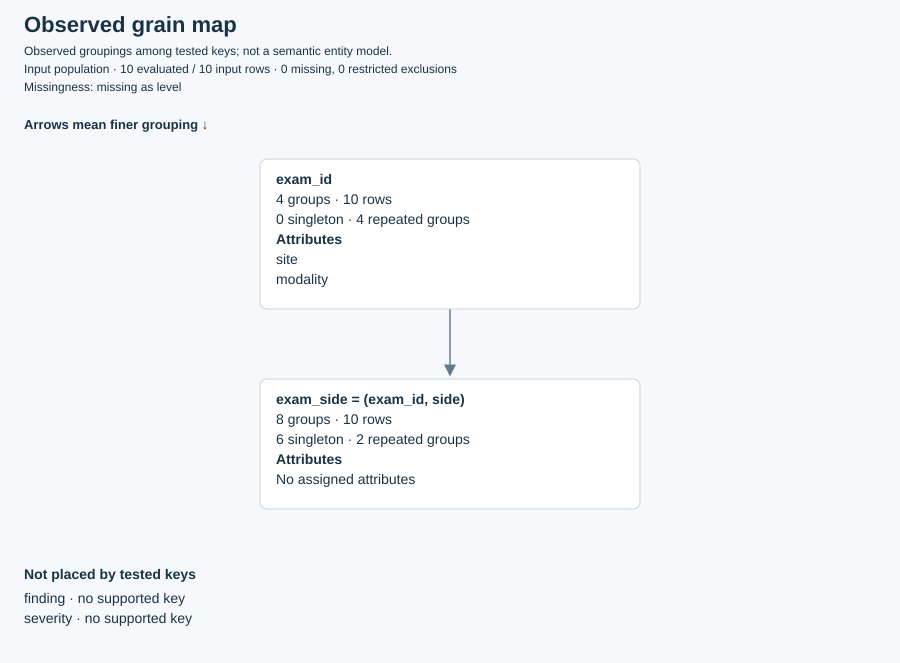

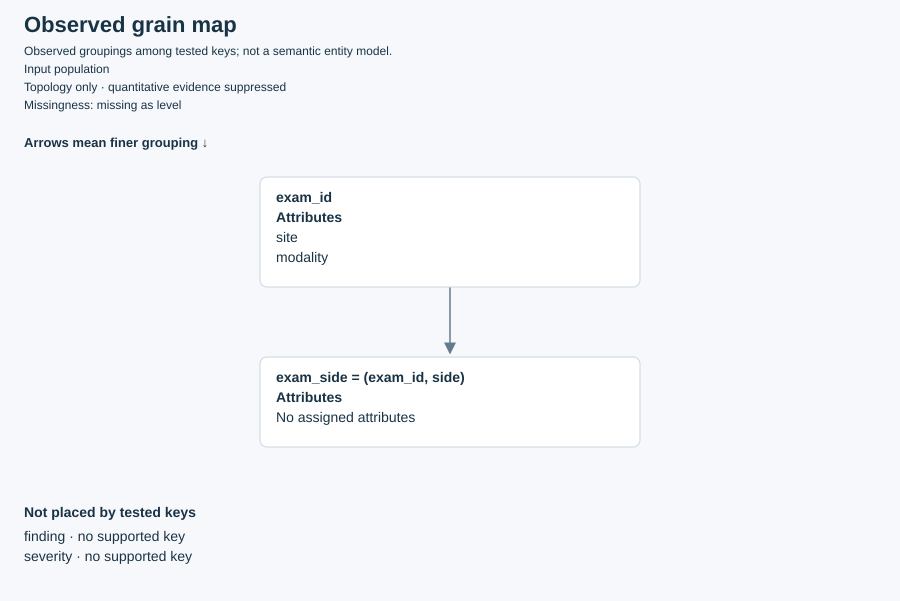

In [12]:
for detail in ("full", "topology"):
    display(HTML(f"<h4>Observed grain · {detail}</h4>"))
    display(SVG(render_svg(grain_result, detail=detail)))

### Matrix and exact-dependency exceptions

The alternate matrix exposes constant, varying, undefined, and untested cells.
The exception overlay adds varying features and, in full mode, their violating
group fractions. Neither view promotes approximate dependencies into the exact
hierarchy.

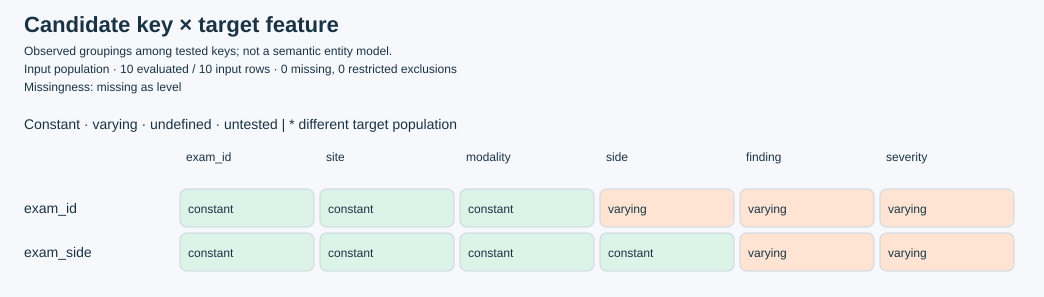

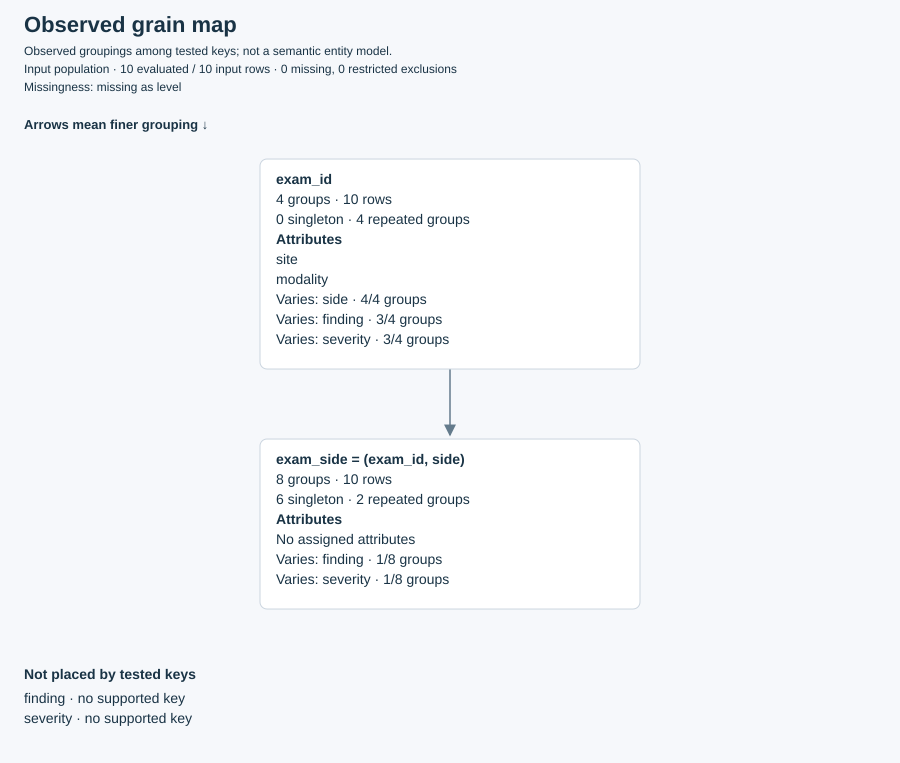

In [13]:
display(SVG(render_svg(grain_result, view="matrix")))
display(SVG(render_svg(grain_result, show_exceptions=True)))

### A small example where the composite resolves the variation

This separate six-row table reproduces the proposal's support pattern. `finding`
varies within one of three exam groups but is constant within all five composite
groups. Four composite groups are singletons, so the support deserves inspection.
The original `df` is unchanged.

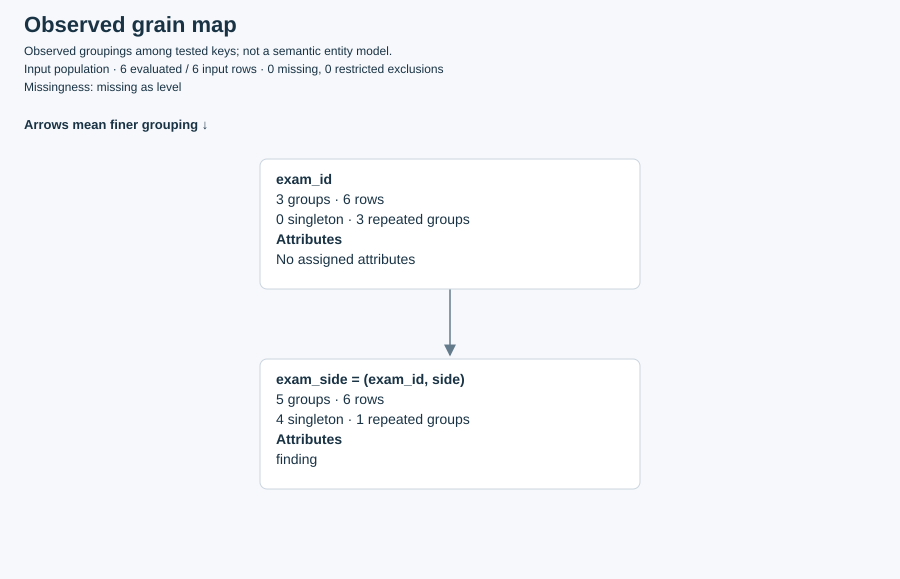

,key_name,holds,evaluated_groups,violating_groups,evaluated_rows,singleton_groups,repeated_groups
0,exam_id,False,3,1,6,0,3
1,exam_side,True,5,0,6,4,1


In [14]:
grain_demo = pd.DataFrame({
    "exam_id": [1, 1, 2, 2, 3, 3],
    "side": ["L", "R", "L", "R", "L", "L"],
    "finding": ["clear", "scar", "clear", "clear", "scar", "scar"],
})
demo_keys = ["exam_id", KeySpec("exam_side", ("exam_id", "side"))]
demo_grain = grain(grain_demo, demo_keys)
display(SVG(render_svg(demo_grain)))

finding_evidence = pd.DataFrame([
    {field: record[field] for field in (
        "key_name", "holds", "evaluated_groups", "violating_groups",
        "evaluated_rows", "singleton_groups", "repeated_groups",
    )}
    for record in demo_grain["graph"]["dependencies"]
    if record["target"]["value"] == "finding"
])
assert finding_evidence["evaluated_groups"].tolist() == [3, 5]
assert finding_evidence["violating_groups"].tolist() == [1, 0]
assert finding_evidence["singleton_groups"].tolist() == [0, 4]
finding_evidence

### Interactive grain controls

In the preview below:

1. Select **finding** in its card or the Feature menu to open its evidence table.
2. Switch **View** to Matrix, then select a feature there.
3. Toggle **Collapse attributes** to compact the cards.
4. Choose a **Focus** key; its neighbors stay highlighted and other links remain visible.
5. Toggle **Show varying features** to expose exact-dependency failures.

Both exports below are self-contained. The topology file omits quantitative
support from its evidence tables as well as from the map.

In [15]:
preview_html(render_html(demo_grain), "grain-demo-full.html")
preview_html(render_html(demo_grain, detail="topology"), "grain-demo-topology.html")

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/grain-demo-full.html


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/grain-demo-topology.html


### Equivalent keys, multiple parents, and shared attributes

`exam_alias` produces the same observed grouping as `exam_id`, so both names share
a card. Exams and sides are cross-cutting parents of the composite. The constant
feature has two incomparable coarsest determinants and appears on both cards as
a shared attribute. The image key refines the composite. No tree is forced.

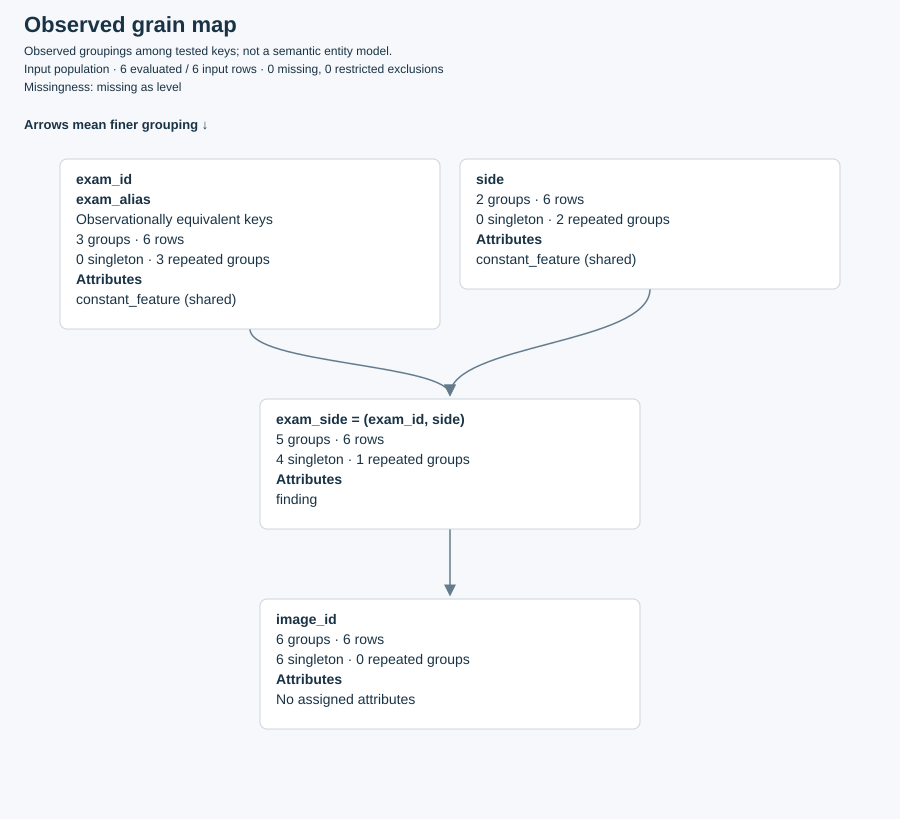

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/grain-dag.html


In [16]:
dag_frame = grain_demo.assign(
    exam_alias=["E1", "E1", "E2", "E2", "E3", "E3"],
    image_id=["I1", "I2", "I3", "I4", "I5", "I6"],
    constant_feature="present",
)
dag_result = grain(dag_frame, [
    "exam_id", "exam_alias", "side",
    KeySpec("exam_side", ("exam_id", "side")), "image_id",
])
assert any(set(node["keys"]) == {"exam_id", "exam_alias"}
           for node in dag_result["graph"]["nodes"])
shared = next(a for a in dag_result["graph"]["assignments"]
              if a["target"]["value"] == "constant_feature")
assert len(shared["nodes"]) == 2
display(SVG(render_svg(dag_result)))
preview_html(render_html(dag_result), "grain-dag.html")

### Missingness changes the evidence scope

With `dropna=True`, the graph first uses rows complete across **all candidate-key
components**. A target requiring further exclusions gets different-population
evidence and remains unplaced. In the original table, the missing `finding` and
`severity` cause this distinction. An asterisk in the matrix marks it. Changing
missingness must not silently merge keys based on a target's smaller population.

,scope_id,input_rows,missing_excluded_rows,restriction_excluded_rows,evaluated_rows,retained_rows,conditional,lineage
0,s3:graph,10,0,0,10,10,False,[]


,target,reason
0,"{'type': 'string', 'value': 'finding'}",different_target_population
1,"{'type': 'string', 'value': 'severity'}",different_target_population


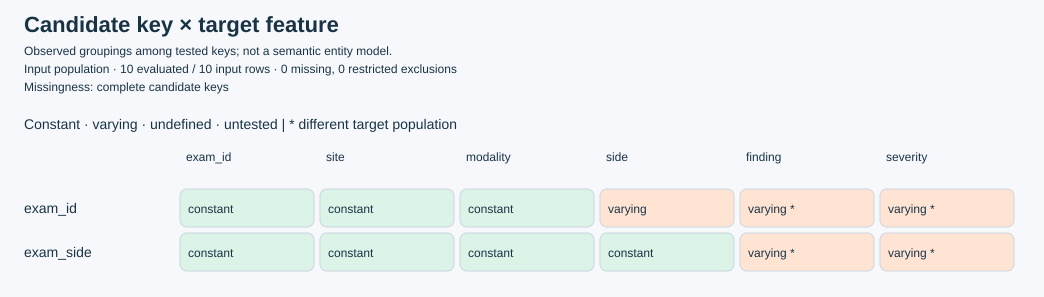

In [17]:
scoped_grain = grain(df, demo_keys, dropna=True)
display(pd.DataFrame([scoped_grain["graph"]["scope"]]))
display(pd.DataFrame(scoped_grain["graph"]["unplaced"]))
assert all(item["reason"] == "different_target_population"
           for item in scoped_grain["graph"]["unplaced"])
display(SVG(render_svg(scoped_grain, view="matrix")))

## 5. Schema proposals are suggestions, not hidden selections

`infer_schema()` reports reviewable cardinality, dtype, missingness, name hints, and optional FD evidence. It does not choose the dimensions or keys for a later analysis.

In [18]:
proposal = infer_schema(df, candidate_keys=["exam_id"])
pd.DataFrame(
    {
        "column": [typed_label(item["column"]) for item in proposal["proposals"]],
        "proposed_role": [item["proposed_role"] for item in proposal["proposals"]],
        "fd_status": [
            item["fd_evidence"]["status"]
            if isinstance(item["fd_evidence"], dict)
            else item["fd_evidence"]
            for item in proposal["proposals"]
        ],
    }
)

,column,proposed_role,fd_status
0,exam_id,categorical,evaluated
1,site,categorical,evaluated
2,modality,categorical,evaluated
3,side,categorical,evaluated
4,finding,categorical,evaluated
5,severity,categorical,evaluated


## 6. Combined exploration, pair relationships, and absence

`explore()` orchestrates the independent surfaces. Here we also declare reference-domain levels that are absent globally (`West`, `PET`, and `U`). Absence totals are exact, while examples are bounded. The plaintext view names the pair columns, states the context and evaluated population, and separates the absence classes. We allow 160 lines here so the combined evidence fits; render an individual section when you need a shorter report. None of the absence classes claim structural impossibility.

In [19]:
combined = explore(
    df,
    dimensions=["site", "modality", "side"],
    features=["site", "modality", "side", "finding"],
    candidate_keys=["exam_id", KeySpec("exam_side", ("exam_id", "side"))],
    include_pairs=True,
    include_absence=True,
    reference_domains={
        "site": ["North", "South", "West"],
        "modality": ["CT", "MRI", "PET"],
        "side": ["L", "R", "U"],
    },
    max_absence_cells=8,
)
print(render_plaintext(combined, width=100, max_lines=160))

bea-tools feature explorer v0.3
Levels (computed)
  site: 2/2 levels; 10/10 evaluated rows reported
    'North': 6 rows
    'South': 4 rows
  modality: 2/2 levels; 10/10 evaluated rows reported
    'CT': 5 rows
    'MRI': 5 rows
  side: 2/2 levels; 10/10 evaluated rows reported
    'L': 6 rows
    'R': 4 rows
  finding: 4/4 levels; 10/10 evaluated rows reported
    'clear': 5 rows
    'nodule': 2 rows
    'scar': 2 rows
    <NA>: 1 row
Census (computed)
  rows: 10 evaluated / 10 input; excluded: 0 missing, 0 restricted
  path: site > modality > side
  total: 10 rows
  site='North': 6 rows
    modality='CT': 3 rows
      side='L': 2 rows
      side='R': 1 row
    modality='MRI': 3 rows
      side='L': 2 rows
      side='R': 1 row
  site='South': 4 rows
    modality='CT': 2 rows
      side='L': 1 row
      side='R': 1 row
    modality='MRI': 2 rows
      side='L': 1 row
      side='R': 1 row
Grain (computed)
  Observed dependencies; sample evidence does not establish semantic grain.
  ex

### Topology-only context for external models

`detail="topology"` retains labels, hierarchy paths, and qualitative relationships while suppressing counts, population sizes, cardinalities, support totals, and association scores. It canonically sorts displayed siblings so frequency-ranked output order does not disclose relative prevalence. This is a presentation filter rather than de-identification: review categorical values, paths, contexts, relationships, and any frequency-based `top_n` selection before sharing the rendered string. Do not share `combined` or `combined.to_dict()` when its quantitative fields must remain internal.

In [20]:
external_context = render_plaintext(
    combined,
    detail="topology",
    width=100,
    max_lines=160,
)
print(external_context)

bea-tools feature explorer v0.3
Topology display (quantitative evidence suppressed)
Levels (computed)
  site
    'North'
    'South'
  modality
    'CT'
    'MRI'
  side
    'L'
    'R'
  finding
    'clear'
    'nodule'
    'scar'
    <NA>
Census (computed)
  path: site > modality > side
  site='North'
    modality='CT'
      side='L'
      side='R'
    modality='MRI'
      side='L'
      side='R'
  site='South'
    modality='CT'
      side='L'
      side='R'
    modality='MRI'
      side='L'
      side='R'
Grain (computed)
  Observed dependencies; sample evidence does not establish semantic grain.
  exam_id [exam_id] -> site
    observed dependency holds
  exam_id [exam_id] -> modality
    observed dependency holds
  exam_id [exam_id] -> side
    observed dependency fails
  exam_id [exam_id] -> finding
    observed dependency fails
  exam_id [exam_id] -> severity
    observed dependency fails
  exam_side [exam_id, side] -> site
    observed dependency holds
  exam_side [exam_id, side

In [21]:
pair_table = pd.DataFrame(
    [
        {
            "pair": " / ".join(str(typed_label(column)) for column in item["columns"]),
            "evaluated_rows": item["evaluated_rows"],
            "relation": item["relation"],
            "cramers_v": item["cramers_v"],
            "observed_cells": item["observed_cells"],
            "absent_cells": item["absence"]["absent_cells"],
            "zero_support_absence": item["absence"]["classes"]["unobserved_zero_support"],
            "bounded_examples": len(item["absence"]["examples"]),
        }
        for item in combined["sections"]["pairs"]["pairs"]
    ]
)
pair_table

,pair,evaluated_rows,relation,cramers_v,observed_cells,absent_cells,zero_support_absence,bounded_examples
0,site / modality,10,n:m,0.000000,4,5,5,5
1,site / side,10,n:m,0.166667,4,5,5,3
2,modality / side,10,n:m,0.000000,4,5,5,0


**How to read relation orientation:** dimensions follow the supplied order. `1:n` means each B maps to one A while at least one A maps to multiple Bs. Pairwise saturation still cannot rule out a higher-order constraint such as XOR.

### Pair matrices and contextual comparisons

A combined result uses `section=` to choose a graphical surface; it defaults to
grain when candidate keys were requested. For a contextual pair demonstration,
we analyze `exam_id` and `finding` globally and within each site. The same feature
ordering is retained across contexts. Pair contexts must be disjoint from the
analyzed dimensions.

Mapping and association are separate encodings. The HTML selector switches
between them; selecting a context retains the global comparison. Hover over a
cell to inspect its population. Topology permits only the mapping layer.

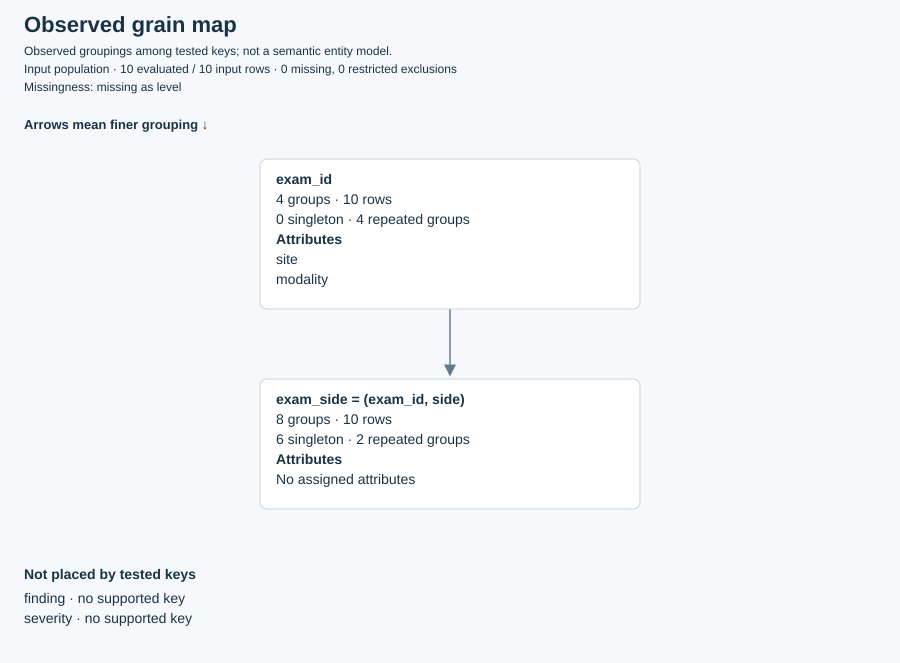

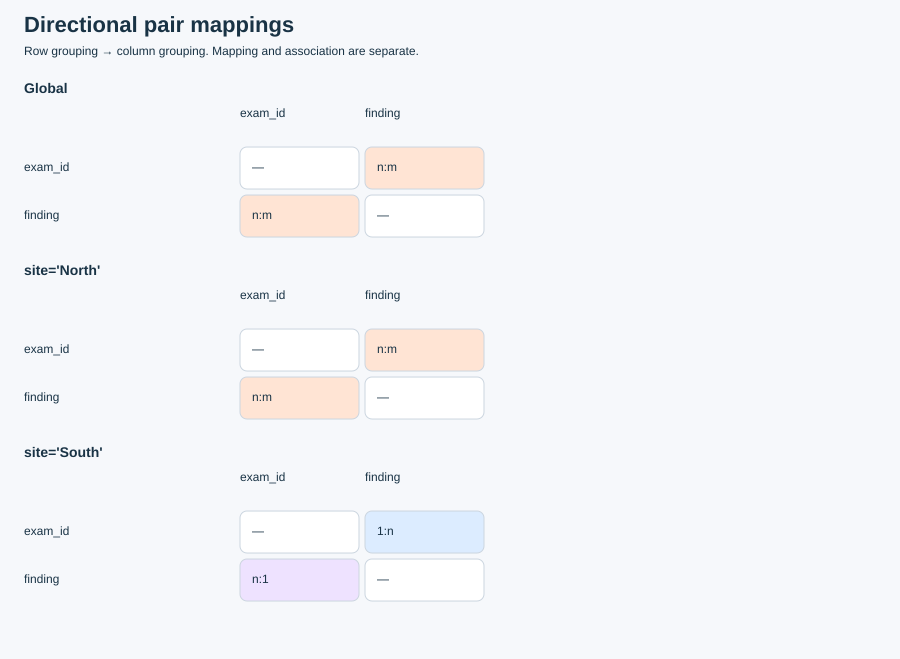

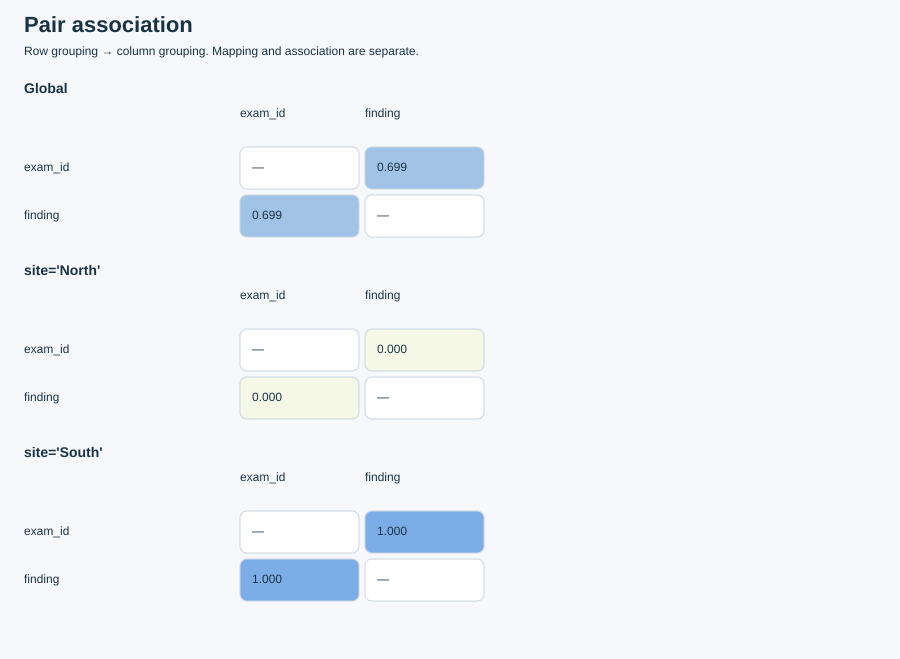

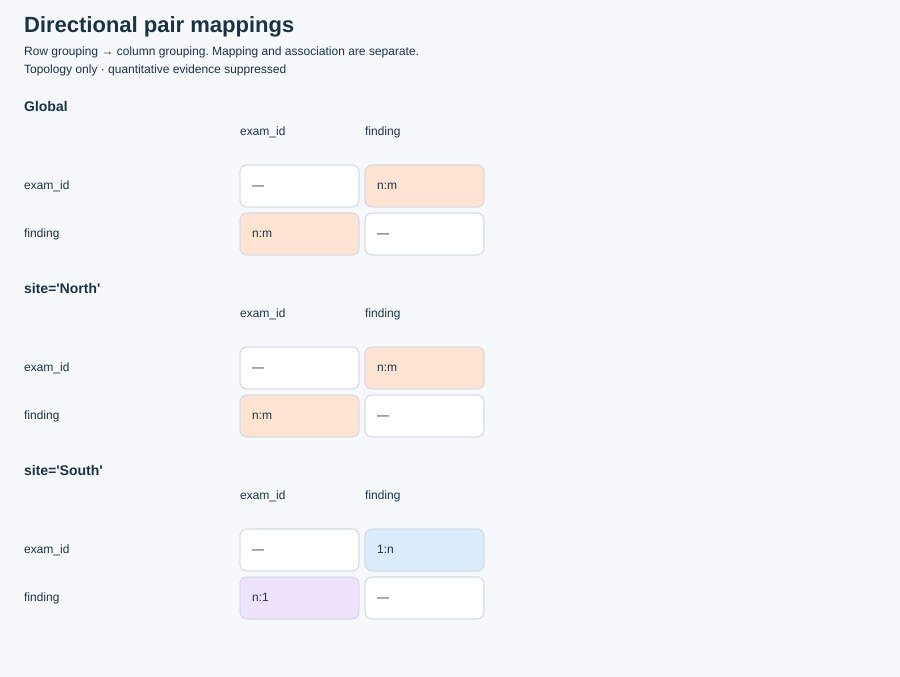

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/pairs-contexts-full.html


In [22]:
# The grain section is the default graphical surface of explore().
display(SVG(render_svg(combined)))

contextual = explore(
    df, dimensions=["exam_id", "finding"],
    pair_contexts=[{"site": "North"}, {"site": "South"}],
)
# North is many-to-many; South's findings each belong to one exam.
assert [pair["relation"] for pair in contextual["sections"]["pairs"]["pairs"]] == [
    "n:m", "n:m", "1:n",
]
display(SVG(render_svg(contextual, section="pairs", view="mapping")))
display(SVG(render_svg(contextual, section="pairs", view="association")))
display(SVG(render_svg(contextual, section="pairs", detail="topology")))
preview_html(render_html(contextual, section="pairs"), "pairs-contexts-full.html")

### On-demand joint cells

`joint_counts()` computes a selected pair's actual joint frequencies, without
expanding every ordinary pair summary. Edit the context below or set it to `None`.
Full heatmaps encode counts; topology uniformly marks observed cells. Blank cells
are unobserved in the stated population, not impossible.

The `max_cells` budget covers the supported-domain product, including blank
heatmap cells. Exceeding it raises instead of silently discarding mass.

,scope_id,input_rows,missing_excluded_rows,restriction_excluded_rows,evaluated_rows,retained_rows,conditional,lineage
0,joint,10,0,4,6,6,True,[]


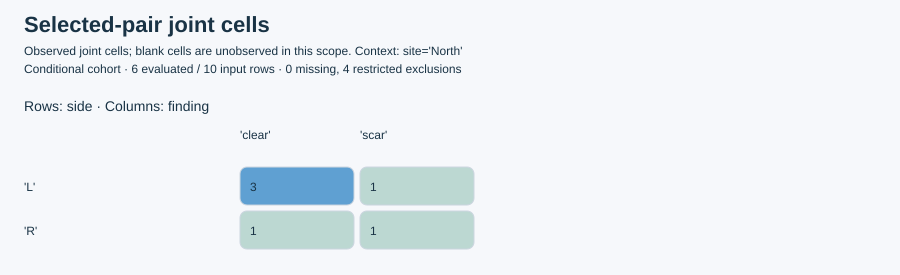

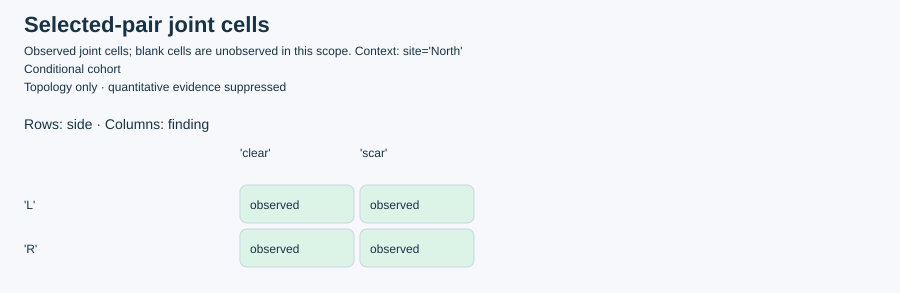

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/joint-counts-full.html
Expected cell-budget guard: Selected pair exceeds max_cells; narrow the context or increase the budget
Expected disclosure guard: Association view requires detail='full'


In [23]:
selected_cells = joint_counts(
    df, ["side", "finding"],
    context={"site": "North"},
    dropna=False,
    max_cells=2500,
)
display(pd.DataFrame(selected_cells["scopes"]))
assert sum(cell["count"] for cell in selected_cells["cells"]) == 6
for detail in ("full", "topology"):
    display(SVG(render_svg(selected_cells, detail=detail)))
preview_html(render_html(selected_cells), "joint-counts-full.html")

# Expected errors are caught so Run All still succeeds.
try:
    joint_counts(df, ["side", "finding"], max_cells=1)
except ValueError as error:
    print("Expected cell-budget guard:", error)

try:
    render_svg(contextual, section="pairs", view="association", detail="topology")
except ValueError as error:
    print("Expected disclosure guard:", error)

### Filtered presentation data for agents and alternative renderers

`visualization_data()` is the projection used before constructing SVG or HTML.
Full projections retain quantitative evidence; topology projections omit it.
Changing row frequencies without changing the observed structure should leave
an unpruned topology projection unchanged. This is a presentation policy, not
de-identification: labels and relationships remain visible.

The notebook intentionally contains full evidence elsewhere. To share only
topology, use an individually named topology export, not this entire notebook or
the original analytical JSON.

In [24]:
structural_summary = visualization_data(demo_grain, detail="topology")
full_summary = visualization_data(demo_grain)
assert "support" in full_summary["nodes"][0]
assert "support" not in structural_summary["nodes"][0]
assert "evaluated_groups" not in structural_summary["evidence"][0]

reweighted_frame = pd.concat([grain_demo, grain_demo.iloc[[0] * 7]], ignore_index=True)
reweighted = grain(reweighted_frame, demo_keys)
assert structural_summary == visualization_data(reweighted, detail="topology")
assert render_svg(demo_grain, detail="topology") == render_svg(reweighted, detail="topology")
assert render_html(demo_grain, detail="topology") == render_html(reweighted, detail="topology")
print("Topology projection and exports are unchanged after reweighting the rows.")
print(json.dumps({key: structural_summary[key] for key in ("scope", "nodes", "edges", "features")},
                 indent=2, ensure_ascii=False))

Topology projection and exports are unchanged after reweighting the rows.
{
  "scope": "Input population",
  "nodes": [
    {
      "id": "g0",
      "titles": [
        "exam_id"
      ],
      "attributes": [],
      "key_names": [
        "exam_id"
      ]
    },
    {
      "id": "g1",
      "titles": [
        "exam_side = (exam_id, side)"
      ],
      "attributes": [
        "f2"
      ],
      "key_names": [
        "exam_side"
      ]
    }
  ],
  "edges": [
    {
      "source": "g0",
      "target": "g1"
    }
  ],
  "features": [
    {
      "id": "f0",
      "label": "exam_id",
      "nodes": [
        "g0"
      ],
      "key_component": true,
      "reason": null
    },
    {
      "id": "f1",
      "label": "side",
      "nodes": [
        "g1"
      ],
      "key_component": true,
      "reason": null
    },
    {
      "id": "f2",
      "label": "finding",
      "nodes": [
        "g1"
      ],
      "key_component": false,
      "reason": null
    }
  ]
}


## 7. Strict JSON and compact parent-linked nodes

Every public result uses standard-library data and schema version `0.3`. Tree nodes store parent and level references rather than repeating full paths.

In [25]:
strict_json = json.dumps(combined.to_dict(), allow_nan=False, sort_keys=True)
print(f"schema={combined['schema_version']}, JSON bytes={len(strict_json.encode('utf-8')):,}")

pd.DataFrame(combined["sections"]["census"]["tree"]["nodes"]).head(8)

schema=0.3, JSON bytes=32,136


,node_id,parent_id,feature_id,level_id,depth,count,share_of_parent,share_of_total,share_reason,expansion_state,omitted_child_rows,omitted_child_levels,stop_reasons
0,n0,root,f0,f0:l0,1,6,0.600000,0.6,None,expanded,0,0,[]
1,n1,root,f0,f0:l1,1,4,0.400000,0.4,None,expanded,0,0,[]
2,n2,n0,f1,f1:l0,2,3,0.500000,0.3,None,expanded,0,0,[]
3,n3,n0,f1,f1:l1,2,3,0.500000,0.3,None,expanded,0,0,[]
4,n4,n1,f1,f1:l0,2,2,0.500000,0.2,None,expanded,0,0,[]
5,n5,n1,f1,f1:l1,2,2,0.500000,0.2,None,expanded,0,0,[]
6,n6,n2,f2,f2:l0,3,2,0.666667,0.2,None,complete,0,0,[]
7,n7,n2,f2,f2:l1,3,1,0.333333,0.1,None,complete,0,0,[]


## 8. Functional API and `DataFrame.bea` are equivalent

The accessor is intentionally thin; it delegates to the same implementation rather than maintaining a second engine.

In [26]:
functional = levels(df, ["site", "side"], top_n=2).to_dict()
accessor = df.bea.levels(["site", "side"], top_n=2).to_dict()
assert functional == accessor
print("Functional and accessor results are identical.")

Functional and accessor results are identical.


## 9. Safe rendering of terminal-sensitive labels

Safe mode is ASCII-only and escapes non-ASCII and terminal controls. Native display mode is available with `bea-tools[unicode]`. All string values are quoted: the literal string `<NA>` remains visibly distinct from a missing value, and strings such as `"1"` remain distinct from numbers. Line truncation is explicitly marked only when more content exists.

In [27]:
adversarial = pd.DataFrame(
    {"label": [None, "<NA>", "snowman ☃", "line\nbreak", "\x1b[31mred"]}
)
safe_text = render_plaintext(levels(adversarial), width=42, max_lines=12)
print(safe_text)
assert "\x1b" not in safe_text

bea-tools feature explorer v0.3
Levels (computed)
  label: 5/5 levels; 5/5 evaluated rows...
    '\x1bred': 1 row
    '<NA>': 1 row
    'line\nbreak': 1 row
    'snowman \u2603': 1 row
    <NA>: 1 row


## 10. Editable graphical playground and exports

Change the settings below, then rerun this cell. Start with `SECTION="grain"`.
Try adding `"site"` to `CANDIDATE_KEYS`, or set `DROPNA=True` to inspect the scope
boundary. `DIMENSIONS` controls the census path; it does not discover entity keys.

Valid static views are:

| Section | `VIEW` choices |
| --- | --- |
| `grain` | `None` (map), `"map"`, `"matrix"` |
| `levels` | `None`, `"bars"` |
| `census` | `None`, `"tree"` |
| `pairs` | `None` (mapping), `"mapping"`, `"association"` (full only) |

`SHOW_EXCEPTIONS` affects the static grain map; HTML exposes its own controls.
The cell writes the SVG, interactive HTML, and filtered presentation JSON into
`OUTPUT_DIR`. Full and topology filenames are distinct. The HTML's initial view
is chosen by its own controls rather than by the SVG-only `VIEW` argument.

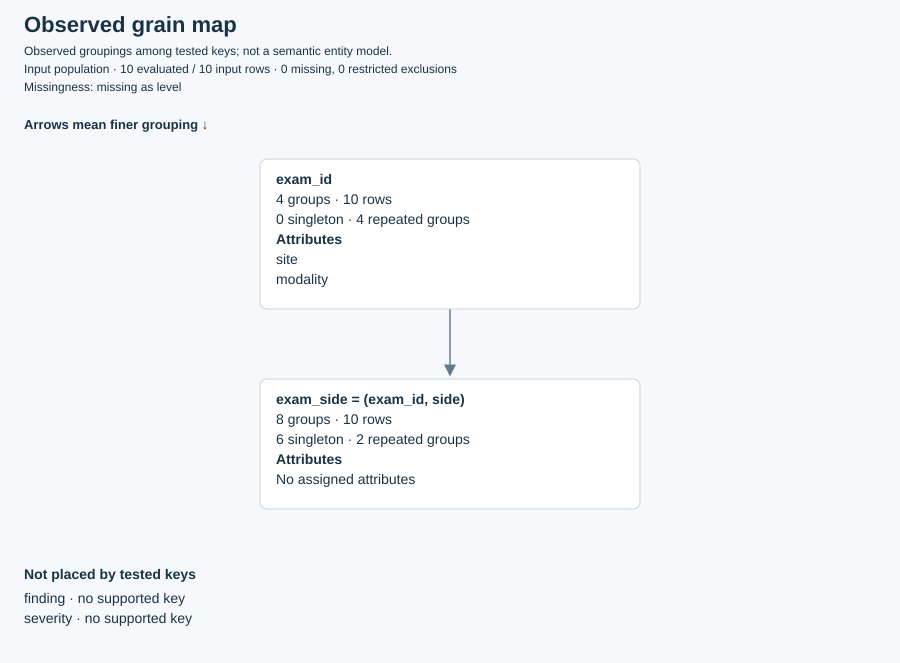

/Users/beatrice/.cache/uv/archive-v0/uk2BtfcqY7AOzasI/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Standalone HTML (open this file if the preview is blocked): /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/playground-grain-full.html
SVG: /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/playground-grain-full.svg
Filtered presentation JSON: /var/folders/b9/w6_2zsyn4t1c8q1b3dyp8jbr0000gn/T/bea-explorer-notebook-501qzx3j/playground-grain-full.json


In [28]:
SECTION = "grain"
DETAIL = "full"  # "full" or "topology"
VIEW = None
SHOW_EXCEPTIONS = False
DROPNA = False
CANDIDATE_KEYS = ["exam_id", KeySpec("exam_side", ("exam_id", "side"))]
DIMENSIONS = ["site", "modality", "side"]
TOP_N = 2
MAX_NODES = 30

playground = explore(
    df,
    dimensions=DIMENSIONS,
    features=["site", "modality", "side", "finding"],
    candidate_keys=CANDIDATE_KEYS,
    top_n=TOP_N,
    max_nodes=MAX_NODES,
    dropna=DROPNA,
)
svg = render_svg(playground, section=SECTION, detail=DETAIL, view=VIEW,
                 show_exceptions=SHOW_EXCEPTIONS)
display(SVG(svg))
base_name = f"playground-{SECTION}-{DETAIL}"
svg_file = OUTPUT_DIR / f"{base_name}.svg"
svg_file.write_text(svg, encoding="utf-8")
preview_html(render_html(playground, section=SECTION, detail=DETAIL), f"{base_name}.html")
projection_file = OUTPUT_DIR / f"{base_name}.json"
projection_file.write_text(json.dumps(
    visualization_data(playground, section=SECTION, detail=DETAIL),
    indent=2, ensure_ascii=False, allow_nan=False,
), encoding="utf-8")
print("SVG:", svg_file)
print("Filtered presentation JSON:", projection_file)

## Suggested review exercises

Try these edits and rerun the relevant cells:

- Change `top_n_per_parent=True` to `False` and compare the retained tree.
- Set `dropna=True` for `levels()` and `grain()` and inspect their separate scopes.
- Remove the conflicting `E001/L` row and confirm that `exam_side → finding` holds.
- Set `max_nodes=0` and inspect totals-only omission accounting.
- Add a `West` row without updating `reference_domains`; the explorer should reject the mismatched declared domain rather than discard the observation.
- Duplicate the whole dataframe and confirm that unpruned counts double while exact FD truth values do not change.

Graphical review exercises:

- Add `"site"` to the playground's candidate keys and inspect the resulting refinement edges.
- Select `finding` in the clean demo's HTML map and compare the exam and composite support tables.
- In the DAG preview, focus `side`, collapse attributes, and confirm that cross-cutting connections remain visible.
- Compare the topology HTML evidence table with its full counterpart; numerical support should be absent.
- Select the North and South pair contexts and switch between mapping and Cramér's V.
- Change the joint-count context to `None`, then lower `max_cells` until the explicit budget guard fires.
- Render `grain(grain_demo.iloc[:0], demo_keys)` as a matrix and inspect undefined evidence.
- Export each playground section in both disclosure modes and open the generated standalone HTML files.

For larger data, remember that exact top-N still scans the eligible rows. Output limits bound representation and deeper expansion; they do not make exact counting sublinear.